In [ ]:
import pandas as pd

# URL for the Adult Income dataset from UCI Machine Learning Repository
url = "https://archive.ics.uci.edu/ml/machine-learning-databases/adult/adult.data"

# Define the column names as given in the dataset description
columns = [
    'age', 'workclass', 'fnlwgt', 'education', 'education-num', 'marital-status',
    'occupation', 'relationship', 'race', 'sex', 'capital-gain', 'capital-loss',
    'hours-per-week', 'native-country', 'income'
]

# Read the dataset from the URL
df_adult_income = pd.read_csv(url, header=None, names=columns, na_values = " ?")

# Confirm the DataFrame is stored correctly by displaying its shape
print("DataFrame shape:", df_adult_income.shape)

# Display the first few rows of the DataFrame
df_adult_income.head()

DataFrame shape: (32561, 15)


,age,workclass,fnlwgt,education,education-num,marital-status,occupation,relationship,race,sex,capital-gain,capital-loss,hours-per-week,native-country,income
0,39,State-gov,77516,Bachelors,13,Never-married,Adm-clerical,Not-in-family,White,Male,2174,0,40,United-States,<=50K
1,50,Self-emp-not-inc,83311,Bachelors,13,Married-civ-spouse,Exec-managerial,Husband,White,Male,0,0,13,United-States,<=50K
2,38,Private,215646,HS-grad,9,Divorced,Handlers-cleaners,Not-in-family,White,Male,0,0,40,United-States,<=50K
3,53,Private,234721,11th,7,Married-civ-spouse,Handlers-cleaners,Husband,Black,Male,0,0,40,United-States,<=50K
4,28,Private,338409,Bachelors,13,Married-civ-spouse,Prof-specialty,Wife,Black,Female,0,0,40,Cuba,<=50K


In [ ]:
print(df_adult_income.isna().sum())

age                  0
workclass         1836
fnlwgt               0
education            0
education-num        0
marital-status       0
occupation        1843
relationship         0
race                 0
sex                  0
capital-gain         0
capital-loss         0
hours-per-week       0
native-country     583
income               0
dtype: int64


In [ ]:
# dropping the naive-country column with null values
df_adult_income.dropna(subset=['native-country'], inplace=True)
df_adult_income


In [ ]:
print(df_adult_income.isna().sum())

age                  0
workclass         1836
fnlwgt               0
education            0
education-num        0
marital-status       0
occupation        1843
relationship         0
race                 0
sex                  0
capital-gain         0
capital-loss         0
hours-per-week       0
income               0
dtype: int64


In [ ]:
#exploring missing values

print(df_adult_income.isna().sum())

age               0
workclass         0
fnlwgt            0
education         0
education-num     0
marital-status    0
occupation        0
relationship      0
race              0
sex               0
capital-gain      0
capital-loss      0
hours-per-week    0
native-country    0
income            0
dtype: int64


In [ ]:
# change categorical features into numerical using one hot encoding
cat_columns= ['workclass', 'education', 'marital-status', 'occupation', 'relationship', 'race', 'sex', 'native-country']

df_encoded = pd.get_dummies(df_adult_income, columns=cat_columns, dtype=int)
df_encoded

,age,fnlwgt,education-num,capital-gain,capital-loss,hours-per-week,income,workclass_ Federal-gov,workclass_ Local-gov,workclass_ Never-worked,...,native-country_ Portugal,native-country_ Puerto-Rico,native-country_ Scotland,native-country_ South,native-country_ Taiwan,native-country_ Thailand,native-country_ Trinadad&Tobago,native-country_ United-States,native-country_ Vietnam,native-country_ Yugoslavia
0,39,77516,13,2174,0,40,<=50K,0,0,0,...,0,0,0,0,0,0,0,1,0,0
1,50,83311,13,0,0,13,<=50K,0,0,0,...,0,0,0,0,0,0,0,1,0,0
2,38,215646,9,0,0,40,<=50K,0,0,0,...,0,0,0,0,0,0,0,1,0,0
3,53,234721,7,0,0,40,<=50K,0,0,0,...,0,0,0,0,0,0,0,1,0,0
4,28,338409,13,0,0,40,<=50K,0,0,0,...,0,0,0,0,0,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
32556,27,257302,12,0,0,38,<=50K,0,0,0,...,0,0,0,0,0,0,0,1,0,0
32557,40,154374,9,0,0,40,>50K,0,0,0,...,0,0,0,0,0,0,0,1,0,0
32558,58,151910,9,0,0,40,<=50K,0,0,0,...,0,0,0,0,0,0,0,1,0,0
32559,22,201490,9,0,0,20,<=50K,0,0,0,...,0,0,0,0,0,0,0,1,0,0


In [ ]:
# decision tree using entropy

from sklearn import tree


X = df_encoded.drop(['income'], axis=1)
y = df_encoded['income']
clf = tree.DecisionTreeClassifier(criterion='gini')
X

,age,fnlwgt,education-num,capital-gain,capital-loss,hours-per-week,workclass_ Federal-gov,workclass_ Local-gov,workclass_ Never-worked,workclass_ Private,...,native-country_ Portugal,native-country_ Puerto-Rico,native-country_ Scotland,native-country_ South,native-country_ Taiwan,native-country_ Thailand,native-country_ Trinadad&Tobago,native-country_ United-States,native-country_ Vietnam,native-country_ Yugoslavia
0,39,77516,13,2174,0,40,0,0,0,0,...,0,0,0,0,0,0,0,1,0,0
1,50,83311,13,0,0,13,0,0,0,0,...,0,0,0,0,0,0,0,1,0,0
2,38,215646,9,0,0,40,0,0,0,1,...,0,0,0,0,0,0,0,1,0,0
3,53,234721,7,0,0,40,0,0,0,1,...,0,0,0,0,0,0,0,1,0,0
4,28,338409,13,0,0,40,0,0,0,1,...,0,0,0,0,0,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
32556,27,257302,12,0,0,38,0,0,0,1,...,0,0,0,0,0,0,0,1,0,0
32557,40,154374,9,0,0,40,0,0,0,1,...,0,0,0,0,0,0,0,1,0,0
32558,58,151910,9,0,0,40,0,0,0,1,...,0,0,0,0,0,0,0,1,0,0
32559,22,201490,9,0,0,20,0,0,0,1,...,0,0,0,0,0,0,0,1,0,0


<Axes: xlabel='income'>

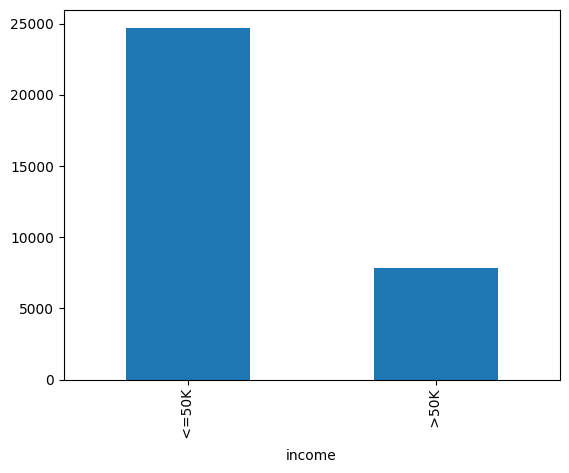

In [ ]:
y.value_counts().plot(kind='bar')

In [ ]:
y

0         <=50K
1         <=50K
2         <=50K
3         <=50K
4         <=50K
          ...  
32556     <=50K
32557      >50K
32558     <=50K
32559     <=50K
32560      >50K
Name: income, Length: 32561, dtype: object

In [ ]:
#splitting into testing and training data
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.20, random_state=10)

X_train.shape, X_test.shape, y_train.shape, y_test.shape

((21815, 105), (10746, 105), (21815,), (10746,))

In [ ]:
y_train

6474      <=50K
12785     <=50K
24072      >50K
14327     <=50K
15789     <=50K
          ...  
28017     <=50K
17728      >50K
29199     <=50K
7293      <=50K
17673     <=50K
Name: income, Length: 21815, dtype: object

In [ ]:
X_train
df_train = pd.DataFrame(X_train)
df_train['income'] = y_train
df_train

,age,fnlwgt,education-num,capital-gain,capital-loss,hours-per-week,workclass_ Federal-gov,workclass_ Local-gov,workclass_ Never-worked,workclass_ Private,...,native-country_ Puerto-Rico,native-country_ Scotland,native-country_ South,native-country_ Taiwan,native-country_ Thailand,native-country_ Trinadad&Tobago,native-country_ United-States,native-country_ Vietnam,native-country_ Yugoslavia,income
6474,37,246677,9,0,0,38,0,0,0,1,...,0,0,0,0,0,0,1,0,0,<=50K
12785,25,120238,9,0,0,40,0,0,0,1,...,0,0,0,0,0,0,0,0,0,<=50K
24072,42,106679,9,0,0,50,0,0,0,1,...,0,0,0,0,0,0,1,0,0,>50K
14327,75,191446,2,0,0,16,0,0,0,1,...,0,0,0,0,0,0,1,0,0,<=50K
15789,38,292307,13,0,0,40,0,0,0,1,...,0,0,0,0,0,0,0,0,0,<=50K
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
28017,27,284741,10,0,0,30,0,0,0,1,...,0,0,0,0,0,0,1,0,0,<=50K
17728,35,287701,12,0,0,45,0,0,0,1,...,0,0,0,0,0,0,1,0,0,>50K
29199,19,264593,10,0,0,40,0,0,0,1,...,0,0,0,0,0,0,1,0,0,<=50K
7293,34,118941,7,0,0,40,0,0,0,1,...,0,0,0,0,0,0,0,0,0,<=50K


In [ ]:
X_test
df_test = pd.DataFrame(X_test)
df_test['income']= y_test
df_test

,age,fnlwgt,education-num,capital-gain,capital-loss,hours-per-week,workclass_ Federal-gov,workclass_ Local-gov,workclass_ Never-worked,workclass_ Private,...,native-country_ Puerto-Rico,native-country_ Scotland,native-country_ South,native-country_ Taiwan,native-country_ Thailand,native-country_ Trinadad&Tobago,native-country_ United-States,native-country_ Vietnam,native-country_ Yugoslavia,income
11358,58,123329,9,0,0,16,0,0,0,0,...,0,0,0,0,0,0,1,0,0,<=50K
10859,23,23438,9,0,0,40,0,1,0,0,...,0,0,0,0,0,0,1,0,0,<=50K
30948,41,433989,11,4386,0,60,0,0,0,1,...,0,0,0,0,0,0,1,0,0,>50K
29811,58,183810,10,0,0,40,0,0,0,1,...,0,0,0,0,0,0,1,0,0,<=50K
18408,47,181130,15,99999,0,50,0,0,0,0,...,0,0,0,0,0,0,1,0,0,>50K
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
31696,90,313986,9,0,0,40,0,0,0,0,...,0,0,0,0,0,0,1,0,0,>50K
26879,41,178431,9,0,0,40,0,0,0,1,...,0,0,0,1,0,0,0,0,0,<=50K
19616,40,170649,10,0,0,8,0,0,0,0,...,0,0,0,0,0,0,1,0,0,<=50K
1960,32,242150,9,0,0,38,0,0,0,1,...,0,0,0,0,0,0,1,0,0,<=50K


In [ ]:
y_test

11358     <=50K
10859     <=50K
30948      >50K
29811     <=50K
18408      >50K
          ...  
31696      >50K
26879     <=50K
19616     <=50K
1960      <=50K
9402      <=50K
Name: income, Length: 10746, dtype: object

In [ ]:
y_train

6474      <=50K
12785     <=50K
24072      >50K
14327     <=50K
15789     <=50K
          ...  
28017     <=50K
17728      >50K
29199     <=50K
7293      <=50K
17673     <=50K
Name: income, Length: 21815, dtype: object

In [ ]:
# training the decision tree classifier
clf.fit(X_train, y_train)

DecisionTreeClassifier(criterion='entropy')

In [ ]:
y_pred= clf.predict(X_test)
print(f"Predicted values: {y_pred}")

print(f"Actual values: {y_test.to_numpy()}")


Predicted values: [' <=50K' ' <=50K' ' >50K' ... ' <=50K' ' <=50K' ' <=50K']
Actual values: [' <=50K' ' <=50K' ' >50K' ... ' <=50K' ' <=50K' ' <=50K']


In [ ]:
# predicting the probability
y_pred_prob = clf.predict_proba(X_test)
print(f"Predicted probabilities: {y_pred_prob}")

Predicted probabilities: [[1. 0.]
 [1. 0.]
 [0. 1.]
 ...
 [1. 0.]
 [1. 0.]
 [1. 0.]]


In [ ]:
# evaluating the metrics

from sklearn.metrics import f1_score


### BEGIN SOLUTION
# your code here
test_f1_score = f1_score(y_test, y_pred, average="weighted")
print(test_f1_score)

### END SOLUTION

0.8176875967765738


In [ ]:
# current depth of the tree
print("The depth of our tree is {}".format(clf.get_depth()))

The depth of our tree is 56


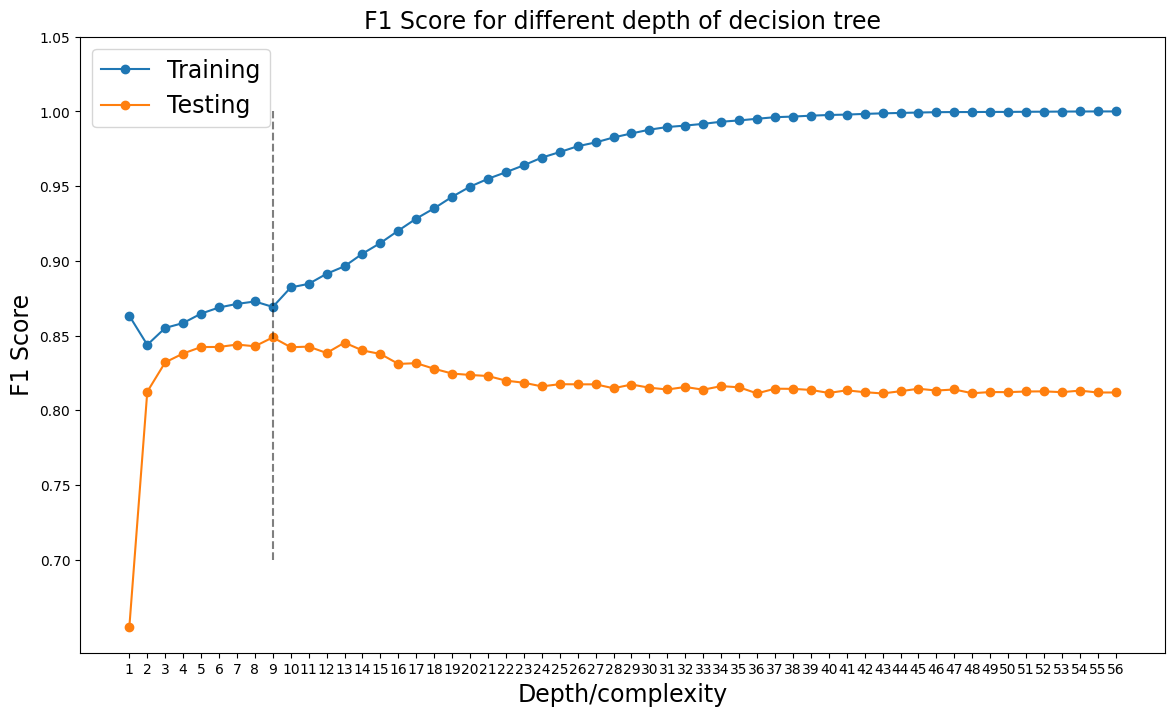

In [ ]:
import matplotlib.pyplot as plt
%matplotlib inline

from sklearn.tree import DecisionTreeClassifier
import numpy as np

train_scores = []
test_socres = []
for i in range(1, clf.get_depth()+1):
    model = DecisionTreeClassifier(random_state=10, max_depth=i).fit(X_train, y_train)

    # Computing f1_score in train set
    y_pred_train = model.predict(X_train)
    train_scores.append(f1_score(y_pred_train, y_train, average='weighted'))# f1_score on train set

    # Computing f1_score on test set
    y_pred = model.predict(X_test) # Making Predictions
    test_socres.append(f1_score(y_test, y_pred, average='weighted'))

max_test_score = np.argmax(test_socres) + 1
# Plot of depth vs accuracy
depth = clf.get_depth()
plt.figure(figsize = (14,8))
plt.plot(np.arange(1, depth+1, 1), train_scores, marker = 'o', label = 'Training')
plt.plot(np.arange(1, depth+1, 1), test_socres, marker = 'o', label = "Testing")
plt.plot([max_test_score,max_test_score], [0.7, 1.0], '--', color = 'black', alpha = 0.5)
plt.xlabel("Depth/complexity", fontsize = 17)
plt.ylabel("F1 Score", fontsize = 17)
plt.title("F1 Score for different depth of decision tree", fontsize = 17)
plt.xticks(np.arange(1, depth+1, 1))
plt.yticks(np.arange(0.7, 1.05, 0.05))
plt.legend(fontsize = 17)
plt.show()

In [ ]:
# setting the optimal depth
optimal_depth = 9

model_new = DecisionTreeClassifier(max_depth=9, random_state=10)
model_new.fit(X_train, y_train)
y_pred = model_new.predict(X_test)
test = f1_score(y_test, y_pred, average='weighted')
print(f"The f1 score is {test}")

print("The depth of our tree is {}".format(model_new.get_depth()))

The f1 score is 0.8487666450109005
The depth of our tree is 9


In [ ]:
!pip install --upgrade scikit-learn


     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 13.3/13.3 MB 72.3 MB/s eta 0:00:00
  Attempting uninstall: scikit-learn
    Found existing installation: scikit-learn 1.2.2
    Uninstalling scikit-learn-1.2.2:
      Successfully uninstalled scikit-learn-1.2.2


In [ ]:
from sklearn import tree

In [ ]:
plt.figure(figsize=(180, 80))
tree.plot_tree(model_new, fontsize=12, impurity=False, proportion=True, rounded=True, precision=2,
          node_ids=False, ax=None)
plt.title("Decision Tree")
plt.show()

In [ ]:
print("The depth of our tree is {}".format(model_new.get_depth()))

The depth of our tree is 9


In [ ]:
from sklearn.metrics import confusion_matrix
cm  = confusion_matrix(y_test, y_pred)
cm

array([[7472,  684],
       [ 915, 1675]])

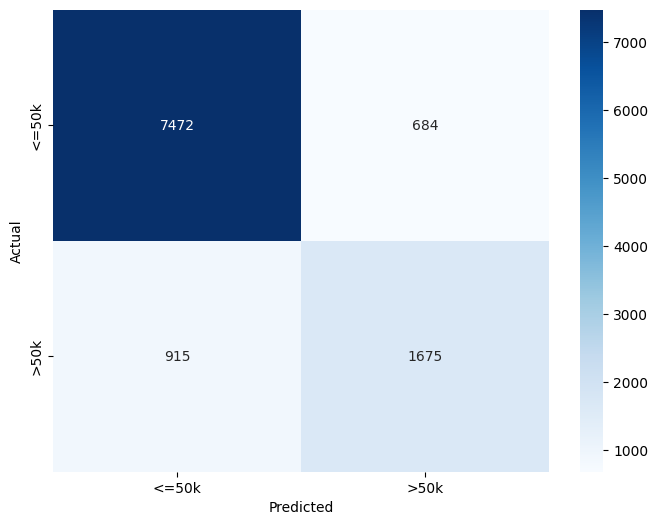

In [ ]:
# visualizing as heatmap

import seaborn as sns
import matplotlib.pyplot as plt

# Define class labels based on your dataset
class_names = [ '<=50k' , '>50k']

# Plotting the heatmap
plt.figure(figsize=(8, 6))  # Adjust the figure size as necessary
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=class_names, yticklabels=class_names)
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

In [ ]:
from sklearn.metrics import classification_report
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

       <=50K       0.89      0.92      0.90      8156
        >50K       0.71      0.65      0.68      2590

    accuracy                           0.85     10746
   macro avg       0.80      0.78      0.79     10746
weighted avg       0.85      0.85      0.85     10746



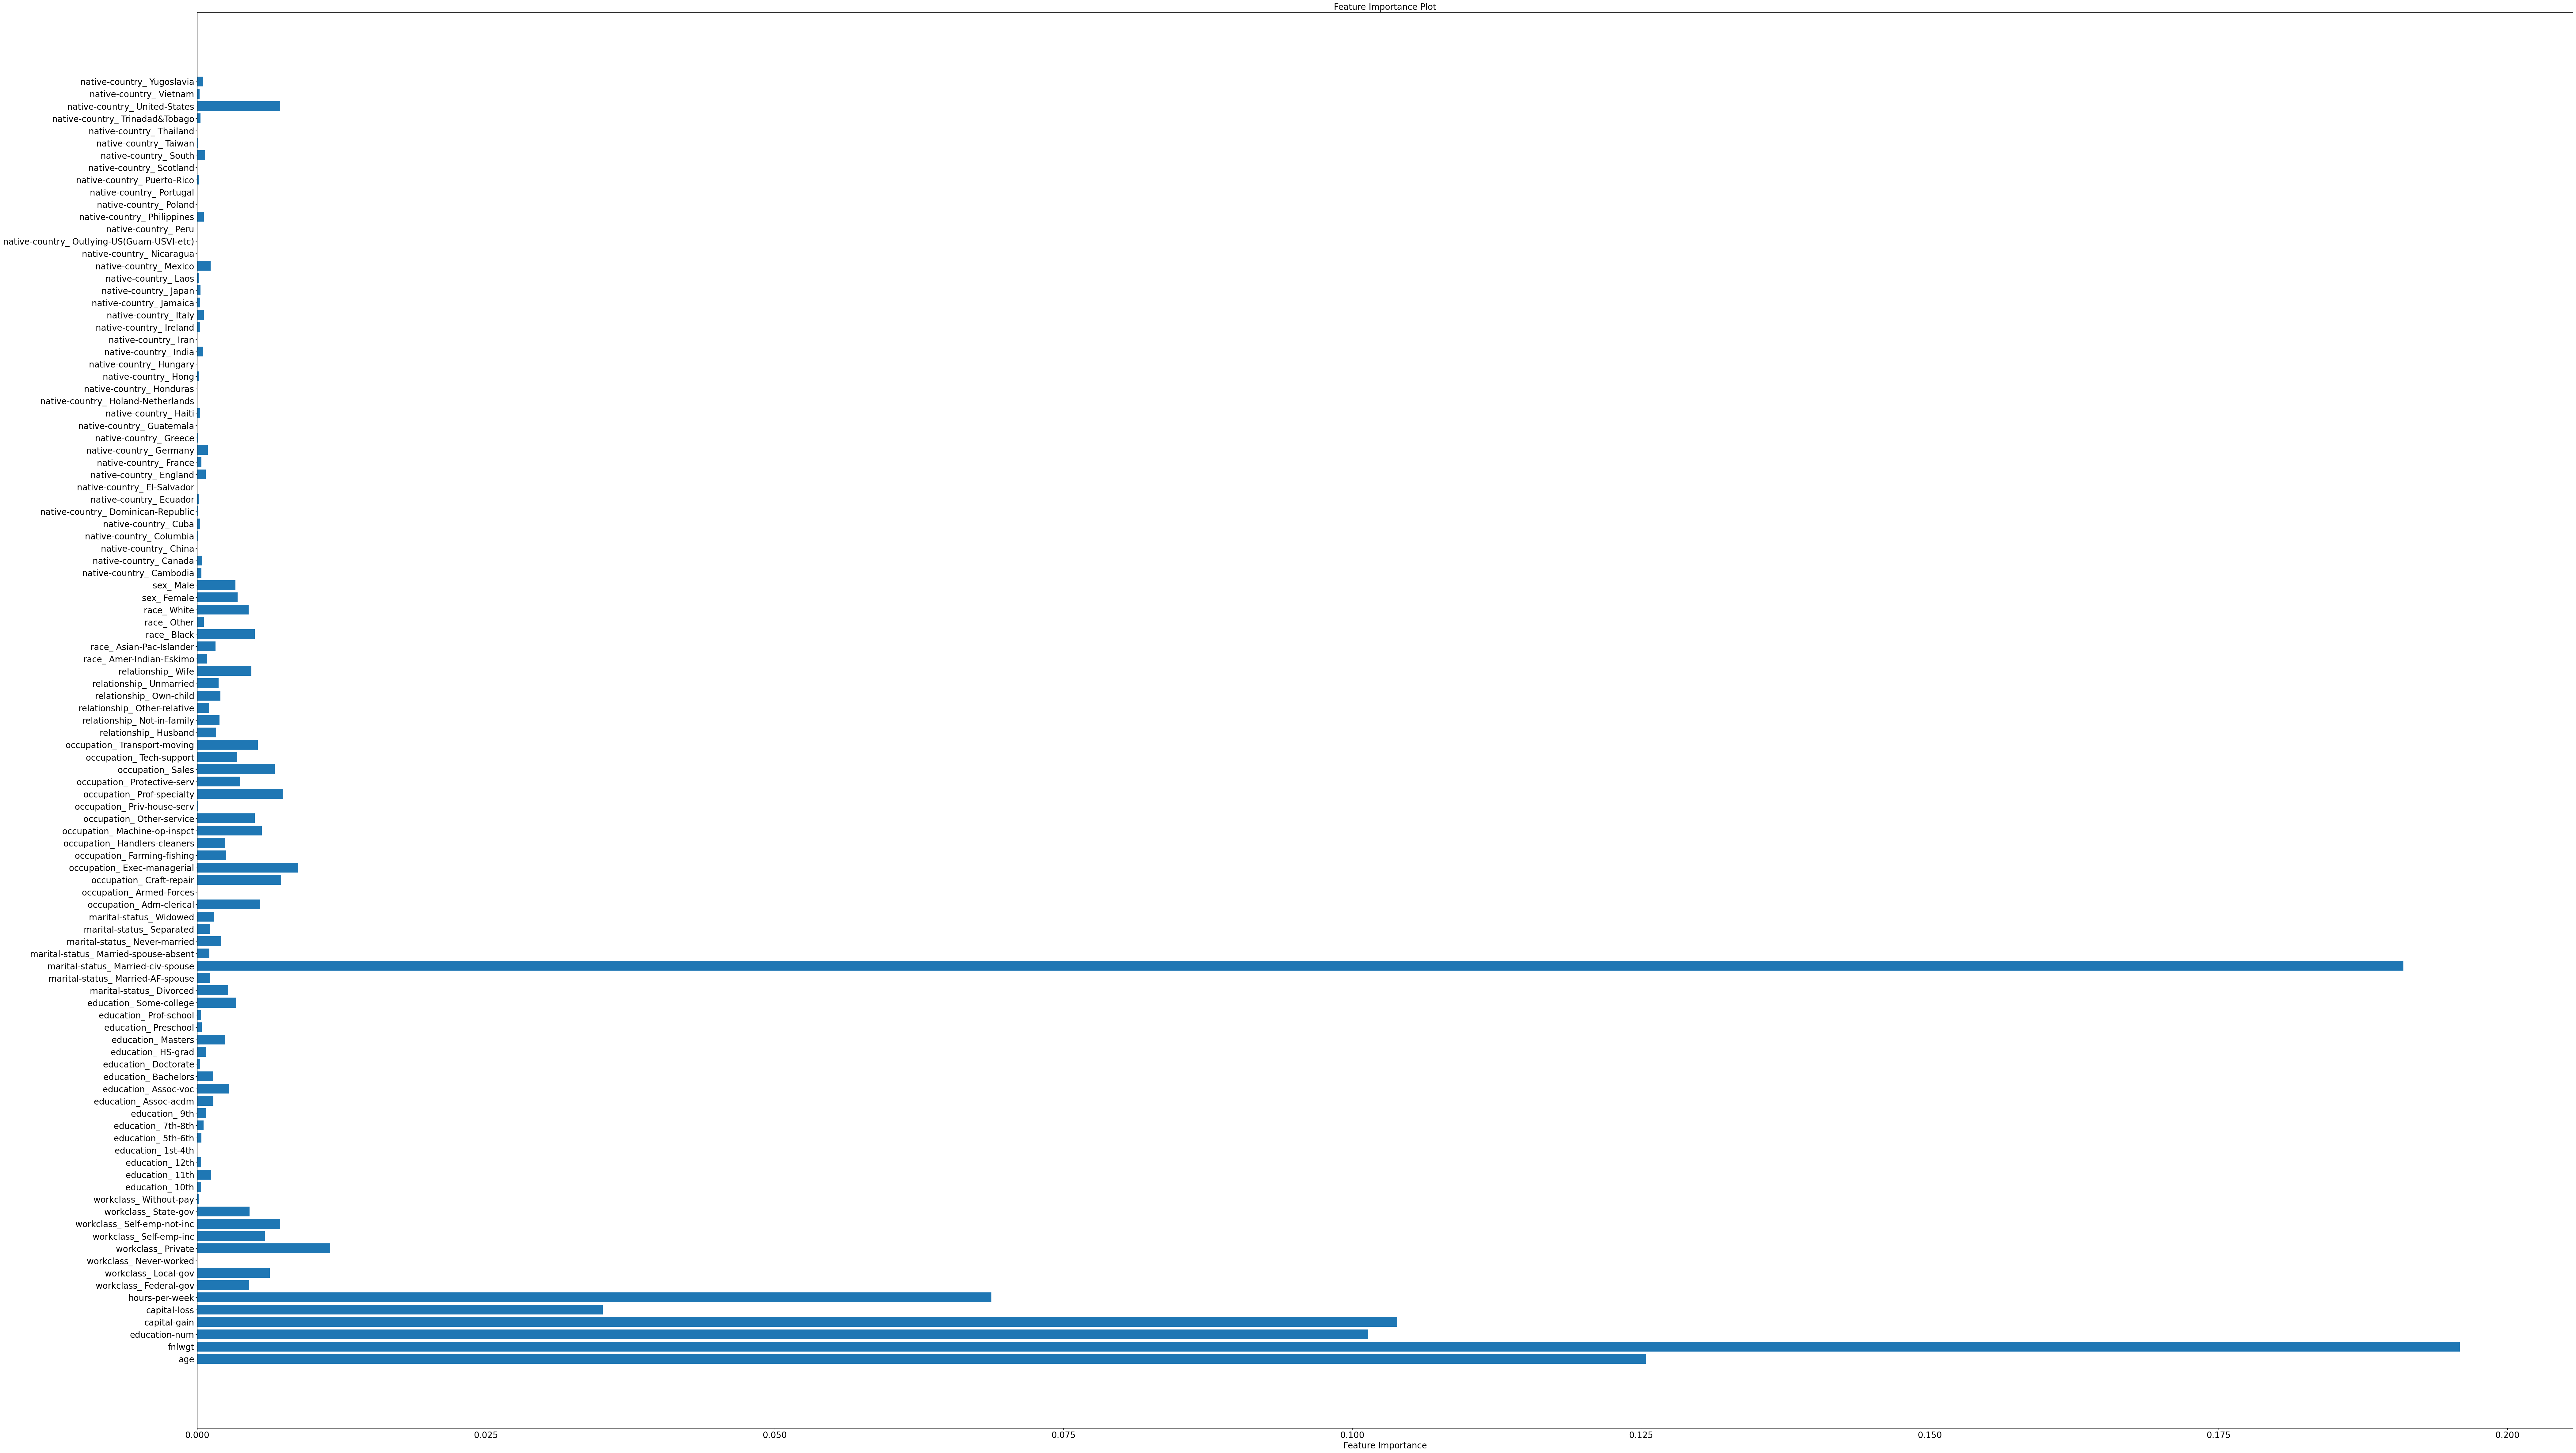

In [ ]:
from sklearn.tree import DecisionTreeClassifier
import matplotlib.pyplot as plt

# Assuming clf is your trained decision tree classifier
clf = DecisionTreeClassifier(criterion='entropy')
clf.fit(X, y)

# Plot feature importances
plt.figure(figsize=(100, 60))
plt.barh(X.columns, clf.feature_importances_)
plt.xlabel('Feature Importance',fontsize=20)
plt.title('Feature Importance Plot',fontsize=20)

# Adjust the size of y-axis tick labels
plt.xticks(fontsize=20)  # Adjust the fontsize here as needed
plt.yticks(fontsize=20)

plt.show()